In [35]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [71]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation :str
    discriminant : float
    result : str


In [72]:
def show_equation(state : QuadState):
    equation = f'{state["a"]}x2{state["b"]}x{state["c"]}'
    return {'equation':equation}

def calculate_discriminant(state: QuadState):
    discriminant = state["b"]**2 - (4*state["a"]*state["c"])
    return {'discriminant': discriminant}

In [73]:
graph =  StateGraph(QuadState)
graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation','calculate_discriminant')
graph.add_edge('calculate_discriminant',END)
workflow =graph.compile()

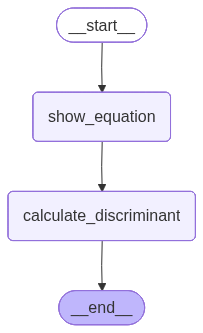

In [74]:
workflow


In [75]:
intial_state = {
    'a':4,
    "b":-5,
    "c":-4
}


workflow.invoke(intial_state)

{'a': 4, 'b': -5, 'c': -4, 'equation': '4x2-5x-4', 'discriminant': 89}

In [76]:
initial_state = {
    'a': 2, 
    'b': 4,
    'c': 2
}

workflow.invoke(initial_state)

{'a': 2, 'b': 4, 'c': 2, 'equation': '2x24x2', 'discriminant': 0}